# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [2]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import urllib.request

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [8]:
df["features"].value_counts()

features
200 m²,4 hab.,Garaje incluido                                           70
200 m²,3 hab.,Garaje incluido                                           56
300 m²,4 hab.,Garaje incluido                                           56
250 m²,4 hab.,Garaje incluido                                           51
150 m²,3 hab.,Garaje incluido                                           49
240 m²,4 hab.,Garaje incluido                                           49
150 m²,4 hab.,Garaje incluido                                           43
300 m²,5 hab.,Garaje incluido                                           41
400 m²,5 hab.,Garaje incluido                                           41
100 m²,3 hab.                                                           38
350 m²,4 hab.,Garaje incluido                                           37
150 m²,3 hab.                                                           35
120 m²,3 hab.                                                           34
220 m²,3 hab.,Ga

## 2. Datos

In [2]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv", index_col = "laptop_ID")
X_pred = pd.read_csv("./data/test.csv", index_col="laptop_ID")

### 2.1 Exploración de los datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [4]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [5]:
df.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [6]:
df.describe()

,Inches,Price_in_euros
count,912.000000,912.000000
mean,14.981579,1111.724090
std,1.436719,687.959172
min,10.100000,174.000000
25%,14.000000,589.000000
50%,15.600000,978.000000
75%,15.600000,1483.942500
max,18.400000,6099.000000


In [7]:
df.groupby("Company")["Price_in_euros"].mean().sort_values()

Company
Vero          235.400000
Chuwi         246.945000
Mediacom      294.333333
Acer          607.613514
Fujitsu       769.000000
Lenovo       1053.578416
Asus         1068.684050
HP           1093.484639
Dell         1173.998680
Xiaomi       1199.616667
Toshiba      1276.558824
Samsung      1423.000000
Huawei       1424.000000
Apple        1540.322353
MSI          1713.425135
Microsoft    1716.970000
Google       1879.000000
LG           2299.000000
Razer        2987.333333
Name: Price_in_euros, dtype: float64

In [8]:
for col in df.columns:
    print(f"{col} : {df[col].value_counts()}")

Company : Company
Lenovo       202
Dell         197
HP           194
Asus         121
Acer          74
MSI           37
Toshiba       34
Apple         17
Razer          6
Mediacom       6
Samsung        5
Microsoft      5
Xiaomi         3
Huawei         2
Chuwi          2
Google         2
Vero           2
Fujitsu        2
LG             1
Name: count, dtype: int64
Product : Product
XPS 13                                           23
Inspiron 3567                                    22
Legion Y520-15IKBN                               15
Vostro 3568                                      14
ProBook 450                                      13
250 G6                                           13
EliteBook 840                                    12
Satellite Pro                                    10
ThinkPad X1                                      10
Alienware 17                                     10
Inspiron 5570                                    10
MacBook Pro                                

### 2.3 Definir X e y

In [9]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 11)

In [10]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [12]:
cols = list(X_train.columns)
cols

['Company',
 'Product',
 'TypeName',
 'Inches',
 'ScreenResolution',
 'Cpu',
 'Ram',
 'Memory',
 'Gpu',
 'OpSys',
 'Weight']

In [13]:
X_train[cols[9]].value_counts()

OpSys
Windows 10      596
No OS            39
Linux            37
Windows 7        24
Chrome OS        14
macOS             7
Mac OS X          6
Windows 10 S      5
Android           1
Name: count, dtype: int64

In [14]:
x = X_train[cols[7]].str.split()
print("------------ Un disco ------------")
print(x[(x.str.len() == 2) & ~(x.astype(str).str.contains("Hybrid"))])
print("------------ Un Hybrid ------------")
print(x[(x.str.len() == 2) & (x.astype(str).str.contains("Hybrid"))])
print("------------ Flash Storage ------------")
print(x[x.str.len() == 3])
print("------------ Hibrido ------------")
print(x[x.str.len() == 5])

------------ Un disco ------------
laptop_ID
1118      [1TB, HDD]
153     [512GB, SSD]
275     [512GB, SSD]
1100    [500GB, HDD]
1126    [500GB, HDD]
203     [256GB, SSD]
853     [128GB, SSD]
1244    [256GB, SSD]
819       [1TB, HDD]
438     [256GB, SSD]
296       [1TB, HDD]
831     [512GB, SSD]
326       [1TB, HDD]
543     [256GB, SSD]
1184    [256GB, SSD]
709     [256GB, SSD]
175       [2TB, HDD]
430       [1TB, HDD]
737       [1TB, HDD]
406       [1TB, SSD]
987     [256GB, SSD]
730     [256GB, SSD]
303       [1TB, HDD]
1080    [256GB, SSD]
542     [256GB, SSD]
876     [500GB, HDD]
1104    [500GB, HDD]
535     [500GB, HDD]
83      [512GB, SSD]
598     [512GB, SSD]
477     [512GB, SSD]
1120    [256GB, SSD]
359     [256GB, SSD]
448     [256GB, SSD]
19        [1TB, HDD]
1206    [256GB, SSD]
551     [500GB, HDD]
651       [1TB, HDD]
264     [512GB, SSD]
211     [256GB, SSD]
569     [512GB, SSD]
165     [256GB, SSD]
965     [256GB, SSD]
910       [1TB, HDD]
923     [256GB, SSD]
1153      

In [15]:
x = X_train[cols[8]].str.split()
print("------------ AMD ------------")
mask_amd = X_train[cols[8]].str.contains("AMD", case=False, na=False)
print(x[mask_amd].str.len().value_counts().sort_index())
print(x[x.astype(str).str.contains("AMD")])
print("------------ Nvidia ------------")
mask_amd = X_train[cols[8]].str.contains("Nvidia", case=False, na=False)
print(x[mask_amd].str.len().value_counts().sort_index())
print(x[x.astype(str).str.contains("Nvidia")])
print("------------ Intel ------------")
mask_amd = X_train[cols[8]].str.contains("Intel", case=False, na=False)
print(x[mask_amd].str.len().value_counts().sort_index())
print(x[x.astype(str).str.contains("Intel")])

------------ AMD ------------
Gpu
2     1
3    43
4    48
Name: count, dtype: int64
laptop_ID
1118         [AMD, FirePro, W6150M]
131              [AMD, Radeon, 530]
1126        [AMD, Radeon, R5, M315]
819          [AMD, Radeon, RX, 580]
543              [AMD, Radeon, 530]
709              [AMD, Radeon, 530]
175              [AMD, Radeon, 520]
737              [AMD, Radeon, 520]
303          [AMD, Radeon, R5, 430]
1104              [AMD, Radeon, R5]
535         [AMD, Radeon, R5, M430]
598              [AMD, Radeon, 530]
448              [AMD, Radeon, 530]
551     [AMD, Radeon, R2, Graphics]
910        [AMD, Radeon, R5, M420X]
1153        [AMD, Radeon, R7, M445]
691          [AMD, Radeon, R5, 520]
426          [AMD, Radeon, RX, 550]
671         [AMD, Radeon, R5, M430]
393          [AMD, FirePro, W5130M]
32                [AMD, Radeon, R2]
13          [AMD, Radeon, Pro, 555]
694              [AMD, Radeon, 520]
184              [AMD, Radeon, 530]
935        [AMD, Radeon, R7, M365X]
377   

In [16]:
gpu = X_train["Gpu"].astype(str)

print("---- INTEL ----")
print(gpu[gpu.str.contains("Intel", case=False, na=False)].value_counts().head(30))

print("---- NVIDIA ----")
print(gpu[gpu.str.contains("Nvidia", case=False, na=False)].value_counts().head(30))

print("---- AMD ----")
print(gpu[gpu.str.contains("AMD", case=False, na=False)].value_counts().head(30))


---- INTEL ----
Gpu
Intel HD Graphics 620           150
Intel HD Graphics 520           110
Intel UHD Graphics 620           43
Intel HD Graphics 400            23
Intel HD Graphics 500            20
Intel HD Graphics                18
Intel HD Graphics 515            10
Intel HD Graphics 505             8
Intel HD Graphics 405             7
Intel HD Graphics 615             7
Intel HD Graphics 6000            5
Intel Iris Plus Graphics 640      4
Intel HD Graphics 630             2
Intel HD Graphics 510             2
Intel Iris Graphics 550           1
Intel Iris Graphics 540           1
Intel Iris Plus Graphics 650      1
Intel Graphics 620                1
Intel Iris Pro Graphics           1
Intel HD Graphics 540             1
Intel HD Graphics 620             1
Intel HD Graphics 5300            1
Name: count, dtype: int64
---- NVIDIA ----
Gpu
Nvidia GeForce GTX 1050       32
Nvidia GeForce 940MX          24
Nvidia GeForce GTX 1060       21
Nvidia GeForce GTX 1050 Ti    20
Nvidia Ge

In [17]:
gpu = X_train["Gpu"].astype(str).str.lower()

mask_nvidia = gpu.str.contains("nvidia", na=False)
mask_intel  = gpu.str.contains("intel", na=False)
mask_amd    = gpu.str.contains("amd", na=False)

def etiquetas(series, n=30):
    return (
        series.str.replace(r"[^a-z0-9\s]", " ", regex=True)
              .str.split()
              .explode()
              .value_counts()
              .head(n)
    )

print("NVIDIA")
print(etiquetas(gpu[mask_nvidia], 40))

print("\nAMD")
print(etiquetas(gpu[mask_amd], 40))

print("\nINTEL")
print(etiquetas(gpu[mask_intel], 40))



NVIDIA
Gpu
nvidia     220
geforce    208
gtx        131
1050        52
940mx       31
1060        21
ti          20
1070        20
930mx       18
quadro      12
960m        10
920mx        9
mx150        8
950m         6
980m         6
930m         5
970m         4
m1200        4
gt           4
920m         4
mx130        3
1050m        2
m1000m       2
m2200m       2
m620         2
1080         2
150mx        2
960          2
1050ti       1
m500m        1
980          1
u            1
039c         1
940m         1
m2000m       1
Name: count, dtype: int64

AMD
Gpu
amd         92
radeon      87
r5          30
530         19
m430        15
r7          10
rx           8
520          7
r4           7
r2           6
m445         5
graphics     5
550          4
m330         4
firepro      3
580          3
m420x        2
m440         2
m420         2
w6150m       1
m315         1
430          1
pro          1
555          1
w5130m       1
560          1
m365x        1
m460         1
540      

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [18]:
target = "Price_in_euros"

In [19]:
def to_gb(s):
    s = s.upper()
    if "TB" in s:
        return float(s.replace("TB", "")) * 1024
    return float(s.replace("GB", ""))

def len2(train_test, col="Memory"):
    x = train_test[col].str.split()

    mask = x.str.len() == 2

    size = x[mask].str[0]
    typ  = x[mask].str[1]

    gb = size.apply(to_gb)

    train_test.loc[mask & (typ == "SSD"), "memory_ssd_gb"] = gb
    train_test.loc[mask & (typ == "HDD"), "memory_hdd_gb"] = gb

def flash(train_test, col="Memory"):
    x = train_test[col].str.split()

    mask = x.str.len() == 3

    size = x[mask].str[0]
    gb = size.apply(to_gb)

    train_test.loc[mask, "memory_flash_gb"] = gb
    
def hybrid_len2(train_test, col="Memory"):
    x = train_test[col].str.split()

    mask = (x.str.len() == 2) & (x.astype(str).str.contains("Hybrid"))

    size = x[mask].str[0]
    gb = size.apply(to_gb)

    train_test.loc[mask, "memory_hybrid_gb"] = gb

def len5(train_test, col="Memory"):
    x = train_test[col].str.split()

    mask = x.str.len() == 5

    size1 = x[mask].str[0]
    type1 = x[mask].str[1]

    size2 = x[mask].str[3]
    type2 = x[mask].str[4]

    gb1 = size1.apply(to_gb)
    gb2 = size2.apply(to_gb)

    train_test.loc[mask & (type1 == "SSD"), "memory_ssd_gb"] += gb1
    train_test.loc[mask & (type1 == "HDD"), "memory_hdd_gb"] += gb1

    train_test.loc[mask & (type2 == "SSD"), "memory_ssd_gb"] += gb2
    train_test.loc[mask & (type2 == "HDD"), "memory_hdd_gb"] += gb2


In [20]:
# ------------------------------------------- Gpu -------------------------------------------
import numpy as np
import pandas as pd
import re

def gpu(df, col="Gpu"):
    s = df[col].astype(str).str.lower()

    df["gpu_is_intel"]  = s.str.contains("intel").astype(int)
    df["gpu_is_nvidia"] = s.str.contains("nvidia").astype(int)
    df["gpu_is_amd"]    = s.str.contains("amd").astype(int)

    df["gpu_num"] = (
        s.str.extract(r"(\d{3,4})", expand=False)
         .astype(float)
    )

    df["gpu_has_letters"] = s.str.contains(r"\d+[a-z]+|[a-z]+\d+", regex=True).astype(int)

    df["gpu_num"] = df["gpu_num"].fillna(df["gpu_num"].median())

    df.drop(columns=[col], inplace=True)

    return df


In [22]:
# ------------------------------------------- CPU -------------------------------------------
def cpu_line(text):
    t = str(text).lower()

    if "intel" in t:
        if "core i3" in t: return "intel_i3"
        if "core i5" in t: return "intel_i5"
        if "core i7" in t: return "intel_i7"
        if "xeon" in t: return "intel_xeon"
        if "celeron" in t: return "intel_celeron"
        if "pentium" in t: return "intel_pentium"
        if "atom" in t: return "intel_atom"
        if "core m" in t: return "intel_core_m"
        return "intel_other"

    if "amd" in t:
        if "ryzen" in t: return "amd_ryzen"
        if any(x in t for x in ["a12", "a10", "a9", "a8", "a6"]):
            return "amd_a_series"
        if "e-series" in t or "e2-" in t:
            return "amd_e_series"
        if "fx" in t:
            return "amd_fx"
        return "amd_other"

    return "other"


In [23]:
X_train.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu',
       'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight'],
      dtype='object')

In [24]:
# ==========================================================
# APLICAR TODAS LAS TRANSFORMACIONES A LA VEZ (train/test/pred)
# ==========================================================

# ------------------------------------------- Product -------------------------------------------
for X in [X_train, X_test, X_pred]:
    if "Product" in X.columns:
        X.drop("Product", axis=1, inplace=True)


# ------------------------------------------- RAM -------------------------------------------
for X in [X_train, X_test, X_pred]:
    X["Ram_GB"] = (
        X["Ram"].astype(str)
        .str.replace("GB", "", regex=False)
        .str.strip()
        .astype(float)
    )
    X.drop("Ram", axis=1, inplace=True)


# ------------------------------------------- Weight -------------------------------------------
for X in [X_train, X_test, X_pred]:
    X["Weight_KG"] = (
        X["Weight"].astype(str)
        .str.replace("kg", "", regex=False)
        .str.strip()
        .astype(float)
    )
    X.drop("Weight", axis=1, inplace=True)


# ------------------------------------------- CPU -------------------------------------------
for X in [X_train, X_test, X_pred]:

    X["cpu_is_intel"] = X["Cpu"].str.contains("Intel", case=False, na=False).astype(int)
    X["cpu_is_amd"]   = X["Cpu"].str.contains("AMD",   case=False, na=False).astype(int)

    X["cpu_ghz"] = (
        X["Cpu"]
        .str.extract(r"(\d+(?:\.\d+)?)\s*GHz", expand=False)
        .astype(float)
    )

    X["cpu_modelo"] = X["Cpu"].apply(cpu_line)

    X.drop(columns=["Cpu"], inplace=True)
    
cpu_cols = [c for c in X_train.columns if "cpu_modelo_" in c]

low_usage = [c for c in cpu_cols if X_train[c].sum() < 7]

X_train.drop(columns=low_usage, inplace=True)
X_test.drop(columns=low_usage, inplace=True)
X_pred.drop(columns=low_usage, inplace=True)


# ------------------------------------------- Memory -------------------------------------------
for X in [X_train, X_test, X_pred]:

    X["memory_ssd_gb"] = 0
    X["memory_hdd_gb"] = 0
    X["memory_flash_gb"] = 0
    X["memory_hybrid_gb"] = 0

    hybrid_len2(X, col="Memory")
    len2(X, col="Memory")
    flash(X, col="Memory")
    len5(X, col="Memory")

    X["memory_total_gb"] = (
        X["memory_ssd_gb"] +
        X["memory_hdd_gb"] +
        X["memory_flash_gb"] +
        X["memory_hybrid_gb"]
    )

    X.drop("Memory", axis=1, inplace=True)


# ------------------------------------------- GPU -------------------------------------------
for X in [X_train, X_test, X_pred]:
    gpu(X, col="Gpu")


# ------------------------------------------- ScreenResolution -------------------------------------------
for X in [X_train, X_test, X_pred]:

    res = X["ScreenResolution"].str.extract(r"(\d+)\s*x\s*(\d+)")
    X["screen_width"] = res[0].astype(float)
    X["screen_height"] = res[1].astype(float)

    X["pixel_count"] = X["screen_width"] * X["screen_height"]

    X.drop("ScreenResolution", axis=1, inplace=True)


# ------------------------------------------- Inches -------------------------------------------
for X in [X_train, X_test, X_pred]:
    X["Inches"] = pd.to_numeric(X["Inches"], errors="coerce")


# ------------------------------------------- Company -------------------------------------------
counts = X_train["Company"].value_counts()
companies_cond = counts[counts <= 4].index

for x in [X_train, X_test, X_pred]:
    x["Company"] = x["Company"].replace(companies_cond, "Other")

# ------------------------------------------- OHE -------------------------------------------
cat_ohe = ["TypeName", "Company", "OpSys", "cpu_modelo"]

X_train = pd.get_dummies(X_train, columns=cat_ohe, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=cat_ohe, dtype=int)
X_pred  = pd.get_dummies(X_pred,  columns=cat_ohe, dtype=int)

# ------------------------------------------- Alinear columnas -------------------------------------------
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)


In [25]:
X_train.columns

Index(['Inches', 'Ram_GB', 'Weight_KG', 'cpu_is_intel', 'cpu_is_amd',
       'cpu_ghz', 'memory_ssd_gb', 'memory_hdd_gb', 'memory_flash_gb',
       'memory_hybrid_gb', 'memory_total_gb', 'gpu_is_intel', 'gpu_is_nvidia',
       'gpu_is_amd', 'gpu_num', 'gpu_has_letters', 'screen_width',
       'screen_height', 'pixel_count', 'TypeName_2 in 1 Convertible',
       'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook',
       'TypeName_Ultrabook', 'TypeName_Workstation', 'Company_Acer',
       'Company_Apple', 'Company_Asus', 'Company_Dell', 'Company_HP',
       'Company_Lenovo', 'Company_MSI', 'Company_Other', 'Company_Toshiba',
       'OpSys_Android', 'OpSys_Chrome OS', 'OpSys_Linux', 'OpSys_Mac OS X',
       'OpSys_No OS', 'OpSys_Windows 10', 'OpSys_Windows 10 S',
       'OpSys_Windows 7', 'OpSys_macOS', 'cpu_modelo_amd_a_series',
       'cpu_modelo_amd_e_series', 'cpu_modelo_amd_fx', 'cpu_modelo_amd_ryzen',
       'cpu_modelo_intel_atom', 'cpu_modelo_intel_celeron',
       'cpu_mo

In [26]:
len(X_train.columns)

55

In [27]:
X_train.head()

,Inches,Ram_GB,Weight_KG,cpu_is_intel,cpu_is_amd,cpu_ghz,memory_ssd_gb,memory_hdd_gb,memory_flash_gb,memory_hybrid_gb,memory_total_gb,gpu_is_intel,gpu_is_nvidia,gpu_is_amd,gpu_num,gpu_has_letters,screen_width,screen_height,pixel_count,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Company_Acer,Company_Apple,Company_Asus,Company_Dell,Company_HP,Company_Lenovo,Company_MSI,Company_Other,Company_Toshiba,OpSys_Android,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,cpu_modelo_amd_a_series,cpu_modelo_amd_e_series,cpu_modelo_amd_fx,cpu_modelo_amd_ryzen,cpu_modelo_intel_atom,cpu_modelo_intel_celeron,cpu_modelo_intel_core_m,cpu_modelo_intel_i3,cpu_modelo_intel_i5,cpu_modelo_intel_i7,cpu_modelo_intel_pentium,cpu_modelo_intel_xeon
laptop_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1118,17.3,8.0,3.00,1,0,2.6,0,1024,0,0,1024,0,0,1,6150.0,1,1920.0,1080.0,2073600.0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
153,15.6,16.0,2.56,1,0,2.8,512,0,0,0,512,0,1,0,1050.0,0,1920.0,1080.0,2073600.0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
275,13.3,8.0,1.37,1,0,2.9,512,0,0,0,512,1,0,0,550.0,0,2560.0,1600.0,4096000.0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1100,14.0,4.0,1.54,1,0,2.3,0,500,0,0,500,1,0,0,520.0,0,1920.0,1080.0,2073600.0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
131,17.3,16.0,2.80,1,0,1.8,256,2048,0,0,2304,0,0,1,530.0,0,1920.0,1080.0,2073600.0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [28]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 1118 to 418
Data columns (total 55 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Inches                       729 non-null    float64
 1   Ram_GB                       729 non-null    float64
 2   Weight_KG                    729 non-null    float64
 3   cpu_is_intel                 729 non-null    int64  
 4   cpu_is_amd                   729 non-null    int64  
 5   cpu_ghz                      729 non-null    float64
 6   memory_ssd_gb                729 non-null    int64  
 7   memory_hdd_gb                729 non-null    int64  
 8   memory_flash_gb              729 non-null    int64  
 9   memory_hybrid_gb             729 non-null    int64  
 10  memory_total_gb              729 non-null    int64  
 11  gpu_is_intel                 729 non-null    int64  
 12  gpu_is_nvidia                729 non-null    int64  
 13  gpu_is_amd            

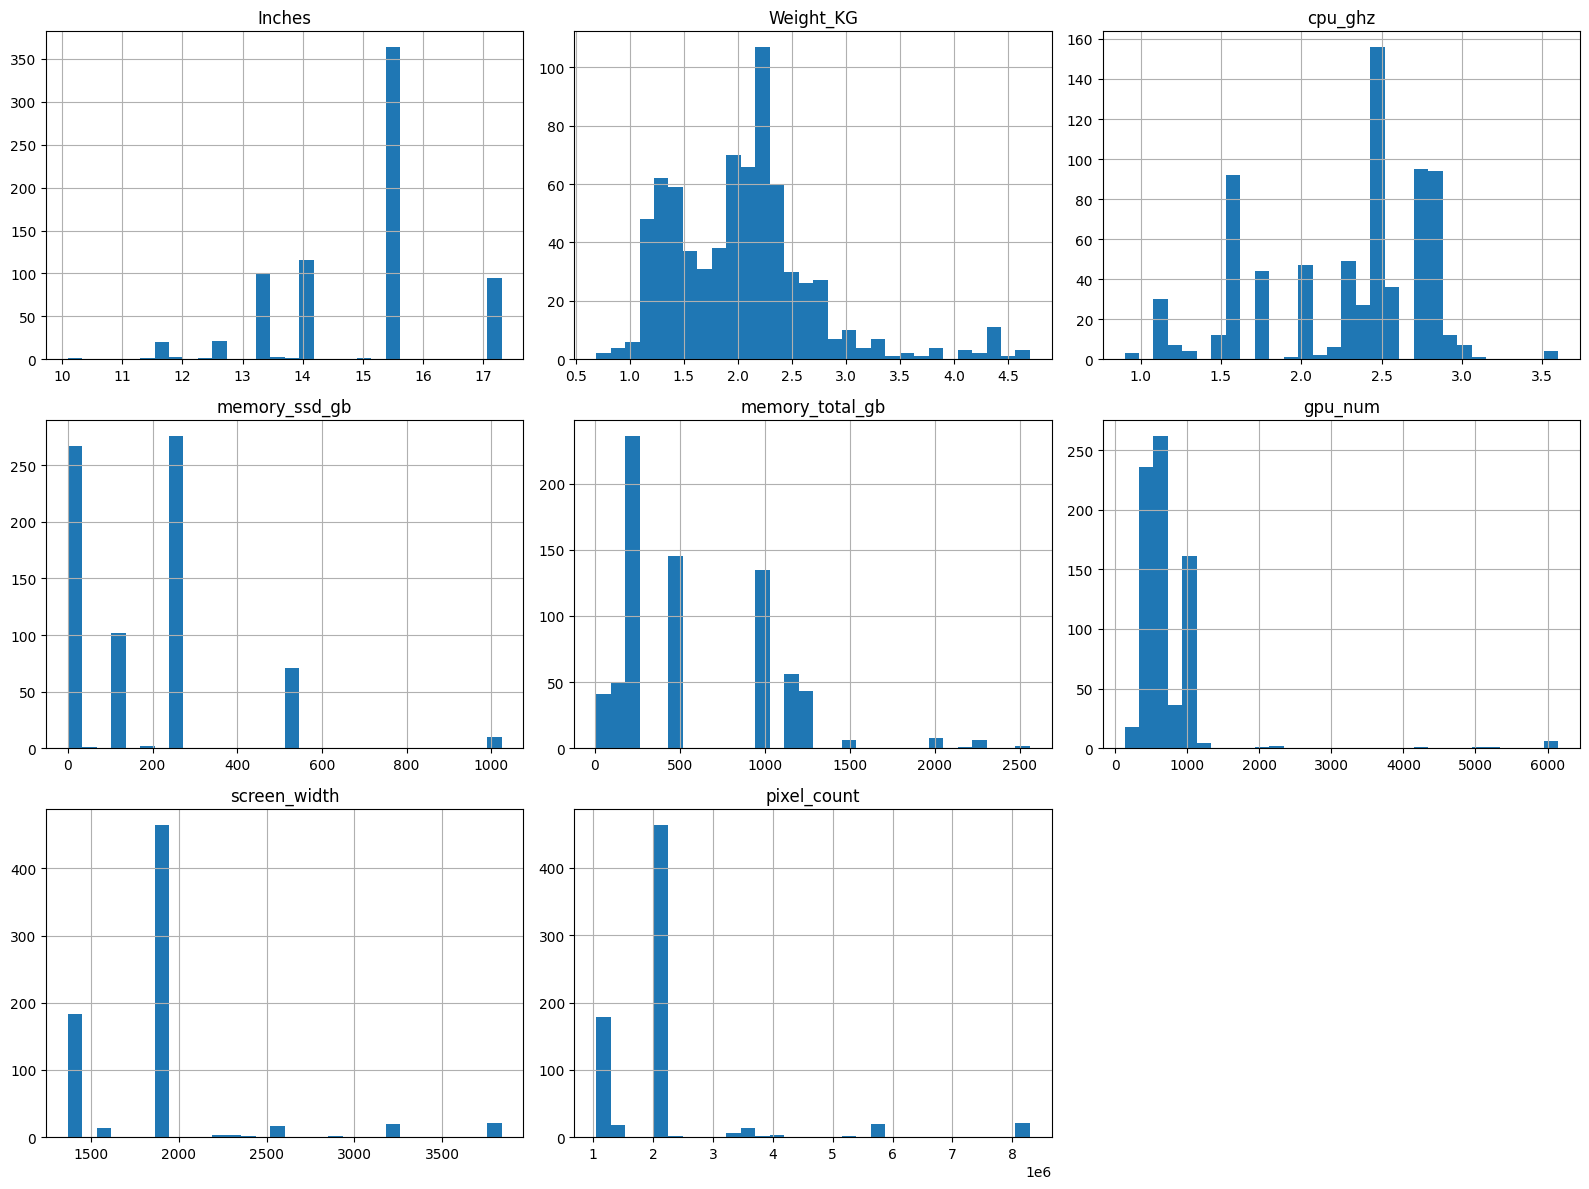

In [ ]:
import matplotlib.pyplot as plt

cont_cols = []

for col in X_train.columns:
    if X_train[col].nunique() > 10:  
        cont_cols.append(col)

X_train[cont_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()


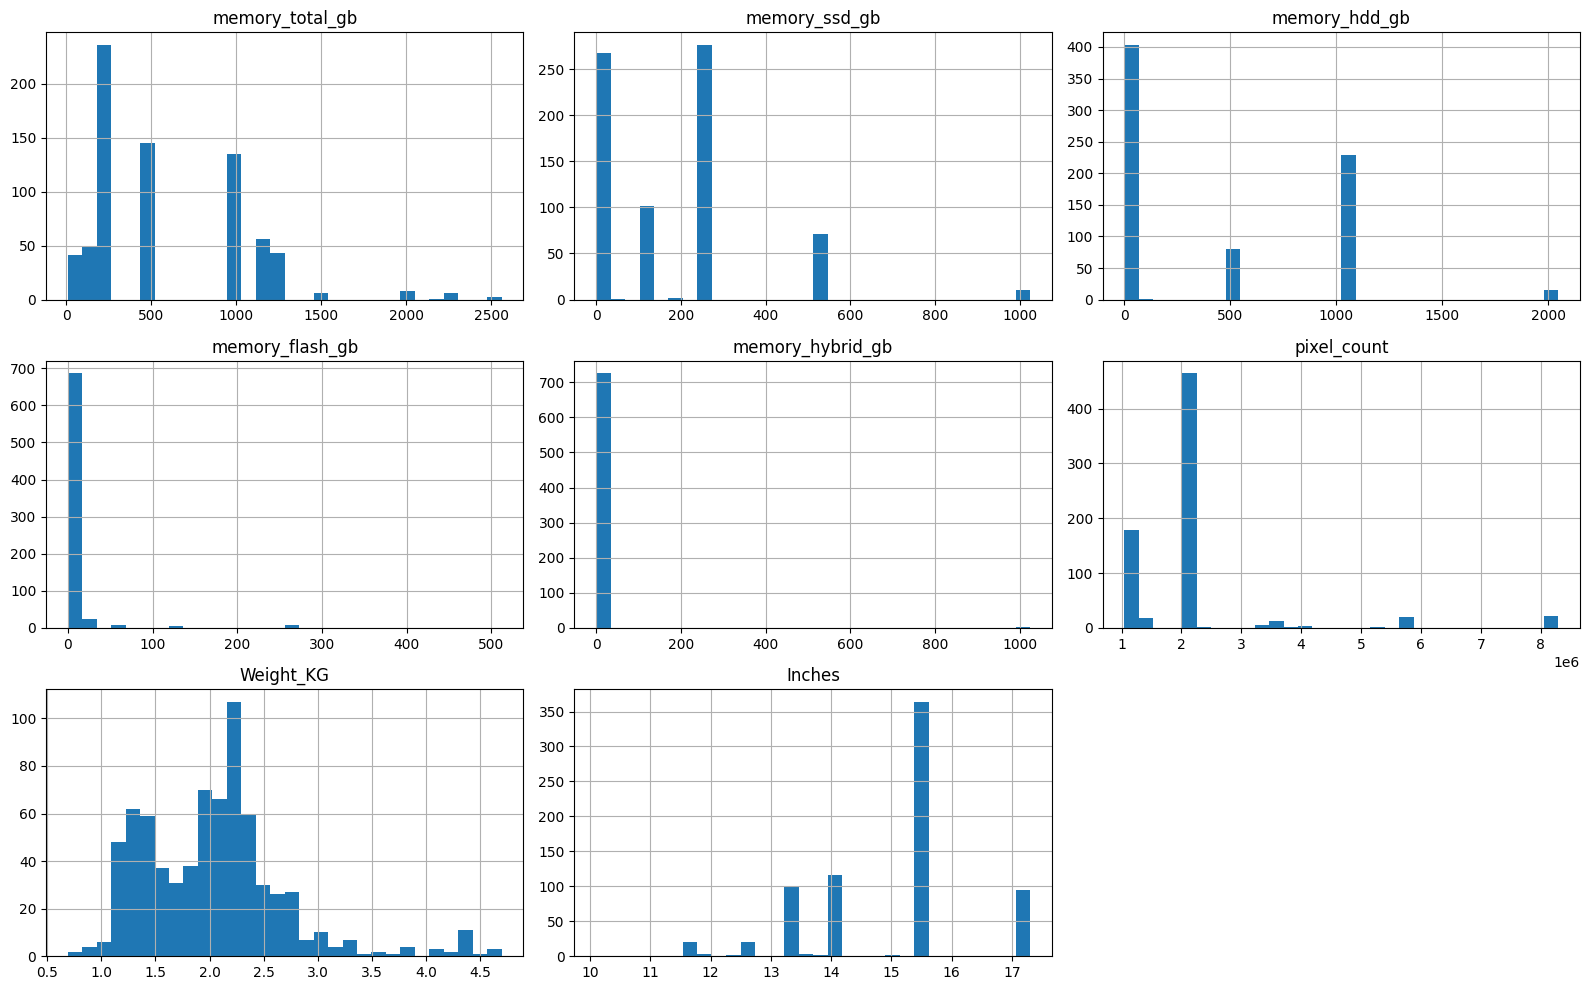

In [30]:
log_candidates = [
    "memory_total_gb",
    "memory_ssd_gb",
    "memory_hdd_gb",
    "memory_flash_gb",
    "memory_hybrid_gb",
    "pixel_count",
    "Weight_KG",
    "Inches"
]

X_train[log_candidates].hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [31]:
# from sklearn.model_selection import GridSearchCV
# rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# param_grid = {
#     "n_estimators": [200, 500],
#     "max_depth": [20, 40, None],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", 0.5],
#     "bootstrap": [True]
# }

# grid = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train, y_train)

# print("Mejores hiperparámetros:", grid.best_params_)
# print("Mejor RMSE CV:", -grid.best_score_)

# best_rf = grid.best_estimator_

In [32]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror")

param_grid_1 = {
    "n_estimators": [300, 600, 1000],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 3]
}

param_grid_2 = {
    "n_estimators": [300, 600, 700],
    "learning_rate": [0.03, 0.05, 0.07],
    "max_depth": [3, 4, 5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "min_child_weight": [1, 3, 5],
    "reg_lambda": [1, 3, 5],
}

param_grid_4 = {
    # Boosting
    "n_estimators": [600, 900, 1200],
    "learning_rate": [0.02, 0.03, 0.05],

    # Tree complexity
    "max_depth": [3, 4, 5],
    "min_child_weight": [1, 3, 5],

    # Regularización (CLAVE para tu caso)
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [1, 2, 3, 5],

    # Sampling (CLAVE anti-overfit)
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_2,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)


param_grid_3 = {
    "n_estimators": [300, 500, 700, 1000, 1300],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],

    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 2, 3, 5, 8, 12],
    "gamma": [0, 0.1, 0.3, 0.5, 1.0, 2.0],

    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],

    "reg_alpha": [0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [1, 2, 3, 5, 7, 10, 15, 25],
}

# search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_grid_3,
#     n_iter=60,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )


grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE CV:", -grid.best_score_)

best_xgb = grid.best_estimator_


Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Mejores hiperparámetros: {'colsample_bytree': 0.5, 'learning_rate': 0.07, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 700, 'reg_lambda': 1, 'subsample': 0.8}
Mejor RMSE CV: 247.3535001993401


In [ ]:
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

best_xgb.fit(X_full, y_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [714]:
# from lightgbm import LGBMRegressor
# from sklearn.model_selection import GridSearchCV

# lgbm = LGBMRegressor(
#     random_state=42,
#     n_jobs=-1
# )

# param_grid = {
#     "n_estimators": [200, 500],
#     "learning_rate": [0.03, 0.05],
#     "max_depth": [-1, 6],
#     "num_leaves": [31, 63],
#     "min_child_samples": [10, 20],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0]
# }
# xgb = XGBRegressor(    random_state=42, n_jobs=-1, objective="reg:squarederror")

# grid = GridSearchCV(
#     estimator=lgbm,
#     param_grid=param_grid,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train, y_train)

# print("Mejores hiperparámetros:", grid.best_params_)
# print("Mejor RMSE CV:", -grid.best_score_)

# best_lgbm = grid.best_estimator_


In [715]:
# from catboost import CatBoostRegressor
# from sklearn.model_selection import GridSearchCV

# cat = CatBoostRegressor(
#     random_state=42,
#     verbose=0
# )

# param_grid = {
#     "iterations": [500, 1000],
#     "depth": [4, 6, 8],
#     "learning_rate": [0.03, 0.05, 0.1],
#     "l2_leaf_reg": [1, 3, 5, 9]
# }

# grid = GridSearchCV(
#     estimator=cat,
#     param_grid=param_grid,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train, y_train)

# print("Mejores hiperparámetros:", grid.best_params_)
# print("Mejor RMSE CV:", -grid.best_score_)

# best_cat = grid.best_estimator_


### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [35]:

from sklearn.metrics import root_mean_squared_error

for name, model in [
    ("XGB", best_xgb)
]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = root_mean_squared_error(y_train, y_pred_train)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)

    print(f"{name} -> RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")


XGB -> RMSE train: 77.605 | RMSE test: 75.272


In [717]:

importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

TypeName_Notebook              0.192796
cpu_modelo_intel_i7            0.168941
Ram_GB                         0.108891
memory_ssd_gb                  0.043608
pixel_count                    0.031560
cpu_modelo_intel_i5            0.030443
gpu_tier_num                   0.027194
gpu_is_quadro                  0.026083
Company_Other                  0.023615
gpu_power_score                0.023158
OpSys_Windows 7                0.021973
gpu_is_iris                    0.015667
screen_width                   0.013674
TypeName_Workstation           0.013219
Inches                         0.013089
gpu_is_amd                     0.012869
Weight_KG                      0.012376
cpu_ghz                        0.011495
screen_height                  0.010475
OpSys_No OS                    0.009639
Company_Asus                   0.008556
OpSys_Windows 10               0.007423
TypeName_Ultrabook             0.007329
gpu_is_hd                      0.007303
memory_flash_gb                0.007046


### 4.3 Optimización (up to you 🫰🏻)

-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


 ## 2. Replicar el procesado para ``test.csv``

In [718]:
predictions_submit = best_xgb.predict(X_pred)
predictions_submit

array([1627.6079 ,  333.65887,  342.53796,  976.83594, 1121.0037 ,
        344.24738,  766.8442 ,  944.75885, 1203.1708 ,  345.028  ,
       2055.5906 , 1381.7745 ,  488.8553 , 1612.7147 ,  774.4312 ,
        716.8455 , 2171.679  , 1341.1208 , 1970.8296 ,  741.00195,
       1552.963  ,  217.72498,  779.2689 , 1180.6708 ,  525.2714 ,
        726.04816,  616.9375 , 1069.6492 , 3265.5566 , 1057.314  ,
       2371.8984 ,  391.3358 ,  937.1221 , 2765.5647 , 2373.381  ,
       1528.8989 ,  649.5205 , 1227.6556 ,  982.07947, 1692.9972 ,
        618.318  ,  795.5364 ,  519.3498 , 1233.3715 , 1243.9026 ,
       1072.6282 , 1065.813  ,  558.63477,  610.6362 ,  436.83368,
       1688.2537 ,  776.9966 , 1103.371  ,  570.868  , 1861.6425 ,
       1723.3174 ,  789.8361 ,  891.6814 ,  976.3539 ,  629.95984,
       2667.215  , 1961.9305 ,  510.1497 , 2140.0845 , 1458.416  ,
       1281.886  , 1075.2129 , 1119.7686 , 1700.71   , 1849.1964 ,
        942.4843 ,  536.31274, 1084.053  , 1690.901  ,  930.34

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [719]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [720]:
sample = pd.read_csv("data/sample_submission.csv")

In [721]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [722]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [723]:
#¿Cómo creamos la submission?
dic_pred = {
    "laptop_ID": X_pred.index,
    "Price_in_euros": predictions_submit
}
submission = pd.DataFrame(dic_pred)

In [724]:
submission.head()


,laptop_ID,Price_in_euros
0,209,1627.607910
1,1281,333.658875
2,1168,342.537964
3,1231,976.835938
4,1020,1121.003662


In [725]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1627.607910
1,1281,333.658875
2,1168,342.537964
3,1231,976.835938
4,1020,1121.003662


In [726]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [727]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [728]:
chequeador(submission)

You're ready to submit!
